# imports

In [1]:

import sionna.rt as rt

import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
import tensorflow as tf
from IPython.display import display   # scene.render() returns a figure, not shows it
from sim import build_rx_path, setup_drone_meshes
from sensing import (
    plot_range_doppler, ground_truth_range_velocity, plot_range_angle,
    world_to_spherical, detect_targets, score_sensing, per_target_sensing_snr,
)
from jcas_drop import run_jcas_drop, plot_jcas_kpis

from sionna.rt import load_scene, PlanarArray, Camera, PathSolver, RadioMapSolver

print(f"Mitsuba variant: {mi.variant()}")
print(tf.config.list_physical_devices('GPU'))


I0000 00:00:1786709414.256696   14373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786709414.294279   14373 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786709415.335896   14373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mitsuba variant: cuda_ad_mono_polarized
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Params

In [2]:
preview = True
tx_power_dbm = 30       # total tx power in dBm, split across users
csi_error_std = 0.00    # stddev of simulated per-entry CSI estimation error (0 = perfect CSI)

# --- Sensing ---
sensing_on = True
plots_on = True         # graphing only; the text metrics always print
render = True           # ray-traced scene image per timestep, paths + ZF radio map
                        # overlaid. Costs a path trace plus a radio map solve per
                        # drone per timestep, which dwarfs the JCAS drop itself.

# create scene

In [3]:
import ofdm_config

# "3.5", "10" or "28" -- rebinds carrier, bandwidth, numerology and array together
ofdm_config.select_band("28")

scene = load_scene(rt.scene.simple_street_canyon, merge_shapes=False)
scene.frequency = ofdm_config.CARRIER_FREQUENCY

scene.tx_array = PlanarArray(num_rows=ofdm_config.ARRAY_ROWS, num_cols=ofdm_config.ARRAY_COLS,
                             pattern="tr38901", polarization="V")
scene.rx_array = scene.tx_array


In [4]:
cameras = {
    "cam2": Camera(position=[0, 0, 270], look_at=[0, 0, 0])
}

# Three UAVs east down the canyon, stacked in altitude and fanned in y so they
# separate in angle, at different speeds so they separate in Doppler too. These
# positions are overwritten each timestep from rx_path; names and colors matter here.
uas1 = rt.Receiver(name="uas_1", position=[-75.0, -10.0, 10.0], orientation=[0.0, 0.0, 0.0])
uas1.color=[1,1,0]
scene.add(uas1)
uas2 = rt.Receiver(name="uas_2", position=[-75.0, 0.0, 25.0], orientation=[0.0, 0.0, 0.0])
uas2.color=[1,0,1]
scene.add(uas2)
uas3 = rt.Receiver(name="uas_3", position=[-75.0, 10.0, 40.0], orientation=[0.0, 0.0, 0.0])
uas3.color=[0,1,1]
scene.add(uas3)

# No standalone Transmitter here: run_jcas_drop() adds its own "bs_tx"/"bs_rx", and
# an extra one would shift the transmitter indexing the ZF precoder reads.

num_drones = 3
num_steps = 5
dt = 1

start_points = tf.constant([
    [-55, 7, 10],  # yellow (low, south side)
    [-55,  0, 25],  # pink   (mid, centerline)
    [-55,  -7, 40]   # cyan   (high, north side)
], dtype=tf.float32)

base_velocities = tf.constant([
    [[20, 0, 0], [20, 0, 0], [20, 0, 0], [20, 0, 0], [20, 0, 0]],
    [[25, 0, 0], [25, 0, 0], [25, 0, 0], [25, 0, 0], [25, 0, 0]],
    [[30, 0, 0], [30, 0, 0], [30, 0, 0], [30, 0, 0], [30, 0, 0]]
], dtype=tf.float32)  # [N, _base_steps, 3] — constant velocity, +x down the corridor

rx_path = build_rx_path(start_points, base_velocities, num_steps, dt, on_mismatch="error")

# One antenna serves comms and sensing alike; run_jcas_drop() reuses these below.
# West end of the canyon, boresight fixed down the corridor. Every drone stays within
# +/-60 deg of it and has nonzero radial velocity, so none lands in the nulled bin.
bs_position = [-60, 1.5, 2]
look_at_point = [70, 0, 20]


I0000 00:00:1786709417.970738   14373 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3965 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
# metal cube per drone: comms multipath scatterer and radar target alike
drone_meshes = setup_drone_meshes(scene, drone_radius_m=0.25)


Sensing t=0: peak power 3.671e-02+0.000e+00j, peak range 12.2m
  uas_1: SNR=-2.6 dB, BER=3.61e-01, throughput=174.9 Mbps  |  uas_2: SNR=29.7 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_3: SNR=19.7 dB, BER=0.00e+00, throughput=273.8 Mbps


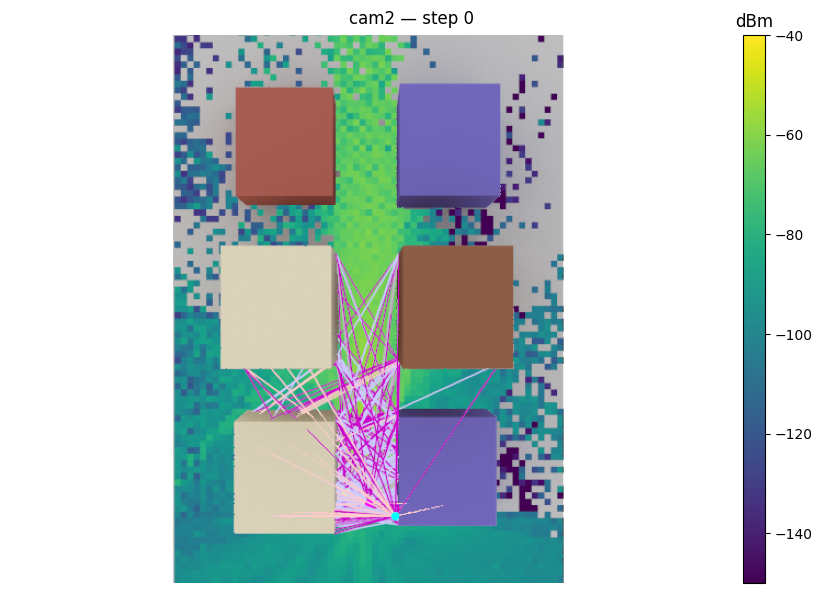

Sensing t=1: peak power 2.512e+00+0.000e+00j, peak range 25.9m
  uas_1: SNR=24.0 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_2: SNR=29.1 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_3: SNR=17.8 dB, BER=0.00e+00, throughput=273.8 Mbps


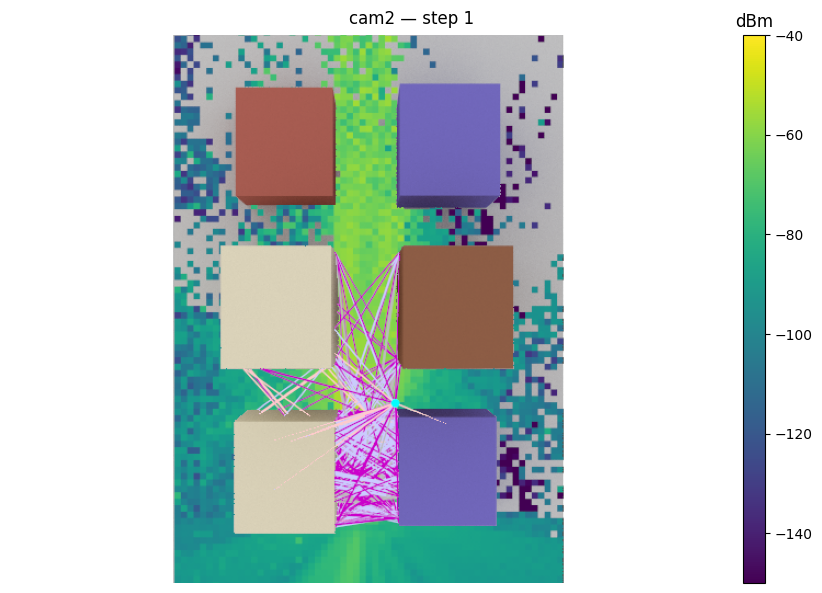

Sensing t=2: peak power 8.946e-01+0.000e+00j, peak range 45.7m
  uas_1: SNR=34.1 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_2: SNR=24.7 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_3: SNR=-10.3 dB, BER=4.31e-01, throughput=155.9 Mbps


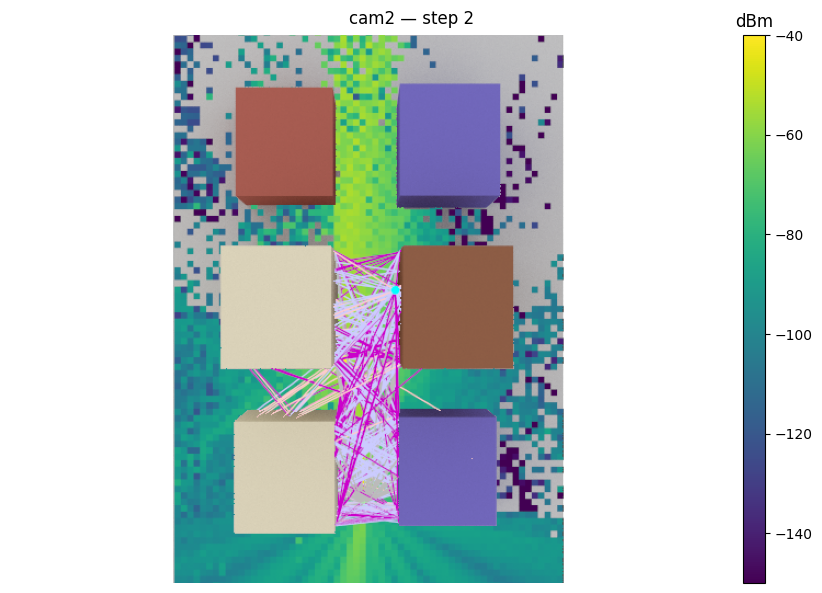

Sensing t=3: peak power 4.229e-01+0.000e+00j, peak range 65.5m
  uas_1: SNR=21.5 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_2: SNR=26.4 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_3: SNR=26.9 dB, BER=0.00e+00, throughput=273.8 Mbps


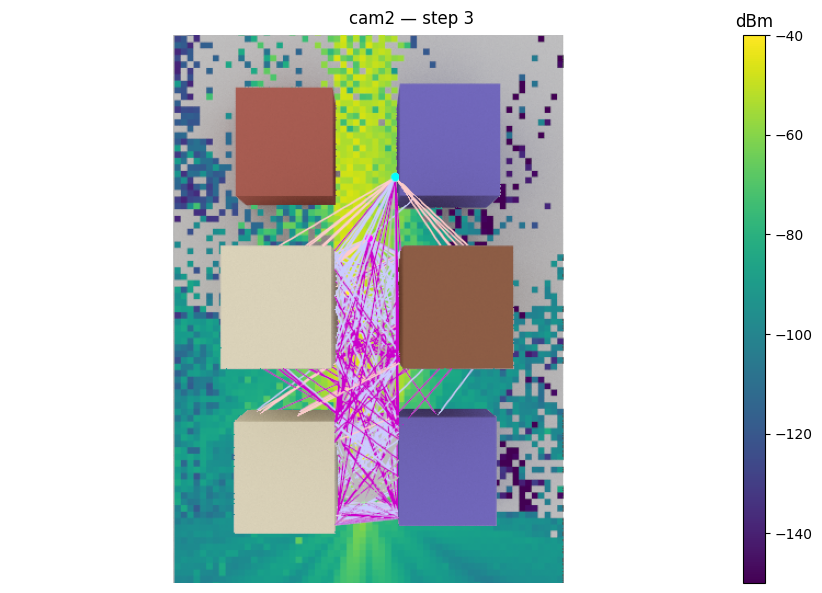

Sensing t=4: peak power 1.519e-01+0.000e+00j, peak range 106.6m
  uas_1: SNR=17.1 dB, BER=3.18e-06, throughput=273.8 Mbps  |  uas_2: SNR=18.3 dB, BER=0.00e+00, throughput=273.8 Mbps  |  uas_3: SNR=22.0 dB, BER=0.00e+00, throughput=273.8 Mbps


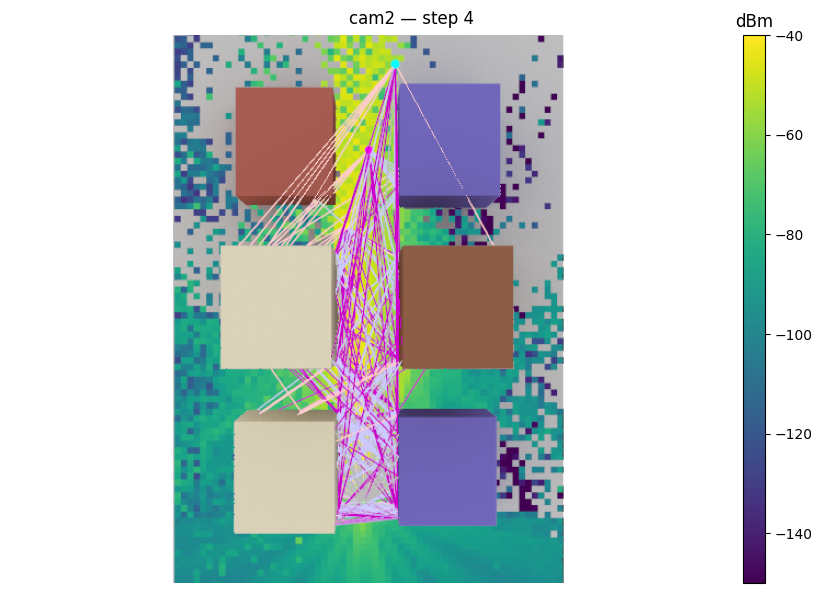

In [6]:
# One PathSolver solve and one jointly ZF-precoded OFDM frame per drone give both the
# RadarCube and the decoded comms links, residual ZF leakage included. See
# jcas_drop.py's docstring for what is simplified.
drone_names = list(scene.receivers)
tx_power_w = 10 ** (tx_power_dbm / 10) / 1000  # dBm → W

sensing_cubes = []            # [T] RadarCube per timestep
sensing_ground_truth = []     # [T] (range_m, velocity_mps) per drone
sensing_ground_truth_pos = [] # [T] drone world positions
jcas_results = []             # [T] JCASDropResult per timestep

if sensing_on:
    for t in range(num_steps):
        truths = []
        positions = []
        for i, name in enumerate(drone_names):
            pos = rx_path[i, t, :].numpy()
            # move the Receiver as well as the mesh: the comms link traces off it
            scene.receivers[name].position = pos.tolist()
            radius = float(np.array(drone_meshes[name].scaling).flat[0])
            mesh_pos = pos.copy()
            mesh_pos[2] += radius  # the z-offset setup_drone_meshes() applied at init
            drone_meshes[name].position = mesh_pos.tolist()
            # velocity is what gives PathSolver a Doppler shift to compute
            t_next = t + 1  # rx_path holds num_steps+1 points
            vel = (rx_path[i, t_next, :] - rx_path[i, t, :]).numpy() / dt
            drone_meshes[name].velocity = vel.tolist()
            truths.append(ground_truth_range_velocity(bs_position, pos, vel))
            positions.append(pos)
        sensing_ground_truth.append(truths)
        sensing_ground_truth_pos.append(positions)

        result = run_jcas_drop(
            scene, bs_position=bs_position, look_at=look_at_point, rx_names=drone_names,
            tx_power_w=tx_power_w, csi_error_std=csi_error_std,
        )
        jcas_results.append(result)
        cube = result.radar_cube
        sensing_cubes.append(cube)

        comms_summary = "  |  ".join(
            f"{name}: SNR={result.comms[name].snr_db:.1f} dB, BER={result.comms[name].ber:.2e}, "
            f"throughput={result.comms[name].throughput_mbps:.1f} Mbps"
            for name in drone_names
        )
        print(f"Sensing t={t}: peak power {cube.data.max():.3e}, "
              f"peak range {cube.range_bins[cube.data.max(axis=(0,1)).argmax()]:.1f}m")
        print(f"  {comms_summary}")

        # Scene + traced paths + the ZF beams the drop actually transmitted through.
        if render:
            # Sionna transmitters default to 44 dBm and rss is path_gain * tx_power,
            # so set the power this run transmits to keep the color scale meaningful.
            scene.transmitters["bs_tx"].power_dbm = tx_power_dbm

            # The drop's Paths object is not kept (~1 GB), so re-trace for the drawing.
            # SBR is stochastic, so individual weak paths may differ.
            render_paths = PathSolver()(
                scene=scene, max_depth=5, refraction=True, los=True,
                diffraction=True, max_num_paths_per_src=5000,
            )

            rm_solver = RadioMapSolver()
            rm_kwargs = dict(
                scene=scene, samples_per_tx=10**6, refraction=True, max_depth=5,
                center=[0, 0, 0.5], orientation=[0, 0, 0], size=[186, 121], cell_size=[2, 2],
            )
            # one radio map per ZF beam, weighted by that drone's equal share of power
            pathgain_combined = None
            for name in drone_names:
                w = np.asarray(result.comms[name].precoding_vector).ravel()
                precoding_vec = (mi.TensorXf(np.ascontiguousarray(w.real, dtype=np.float32)),
                                 mi.TensorXf(np.ascontiguousarray(w.imag, dtype=np.float32)))
                rm_beam = rm_solver(precoding_vec=precoding_vec, **rm_kwargs)
                contribution = rm_beam.path_gain.numpy() / len(drone_names)
                pathgain_combined = contribution if pathgain_combined is None else pathgain_combined + contribution

            # path_gain has no public setter; _pathgain_map is what rm.rss reads
            rm = rm_beam
            rm._pathgain_map = mi.TensorXf(pathgain_combined.astype(np.float32))

            for cam in cameras:
                fig = scene.render(
                    camera=cameras[cam],
                    paths=render_paths,
                    radio_map=rm,
                    num_samples=512,
                    rm_show_color_bar=True,
                    rm_vmax=-40,
                    rm_vmin=-150,
                    rm_metric="rss",
                )
                fig.suptitle(f"{cam} — step {t}")
                display(fig)
                plt.close(fig)

            del render_paths, rm, rm_beam, pathgain_combined  # render-only, free now


In [7]:
# position accuracy, P_d and false alarm rate, from the CFAR detections vs. truth
if sensing_on and sensing_cubes:
    print(score_sensing(sensing_cubes, sensing_ground_truth_pos, bs_position))

    # Two-way (BS -> drone -> BS) SNR, so it obeys 1/R^4 where the comms SNR above is
    # one-way. -inf = no return in that cell; nan = no usable local noise estimate.
    print("\nTwo-way sensing SNR (dB) per drone -- true range/Doppler/bearing cell vs. CFAR noise floor:")
    print("  step  " + "  ".join(f"{name:>9s}" for name in drone_names) + "     range (m)")
    for t_idx, cube in enumerate(sensing_cubes):
        truths_raz = [world_to_spherical(bs_position, pos) for pos in sensing_ground_truth_pos[t_idx]]
        radial_velocities = [v for (_, v) in sensing_ground_truth[t_idx]]
        snrs = per_target_sensing_snr(cube, truths_raz, radial_velocities)
        ranges = "  ".join(f"{r:5.1f}" for (r, _, _) in truths_raz)
        print(f"  {t_idx:>4d}  " + "  ".join(f"{s:>9.1f}" for s in snrs) + f"     {ranges}")

Sensing accuracy (over 5 frame(s), 15 target(s)):
  Detection accuracy (P_d)   : 53.3%  (8/15 targets detected)
  False alarm rate           : 2.80/frame  (4.3% of 323 detections spurious)
  Position accuracy (RMSE)   : 1.36 m   (mean 1.30 m horizontal miss)
    range error (mean)       : 0.59 m
    azimuth error (mean)     : 0.98 deg

Two-way sensing SNR (dB) per drone -- true range/Doppler/bearing cell vs. CFAR noise floor:
  step      uas_1      uas_2      uas_3     range (m)
     0       38.9       26.6       11.5      10.9   23.6   39.3
     1       60.5       43.7       23.3      26.8   37.8   52.4
     2       44.8       48.7       13.0      46.0   59.6   75.8
     3       44.6       -0.8       41.8      65.7   83.3  102.7
     4       34.4       31.5      -15.6      85.6  107.5  130.9


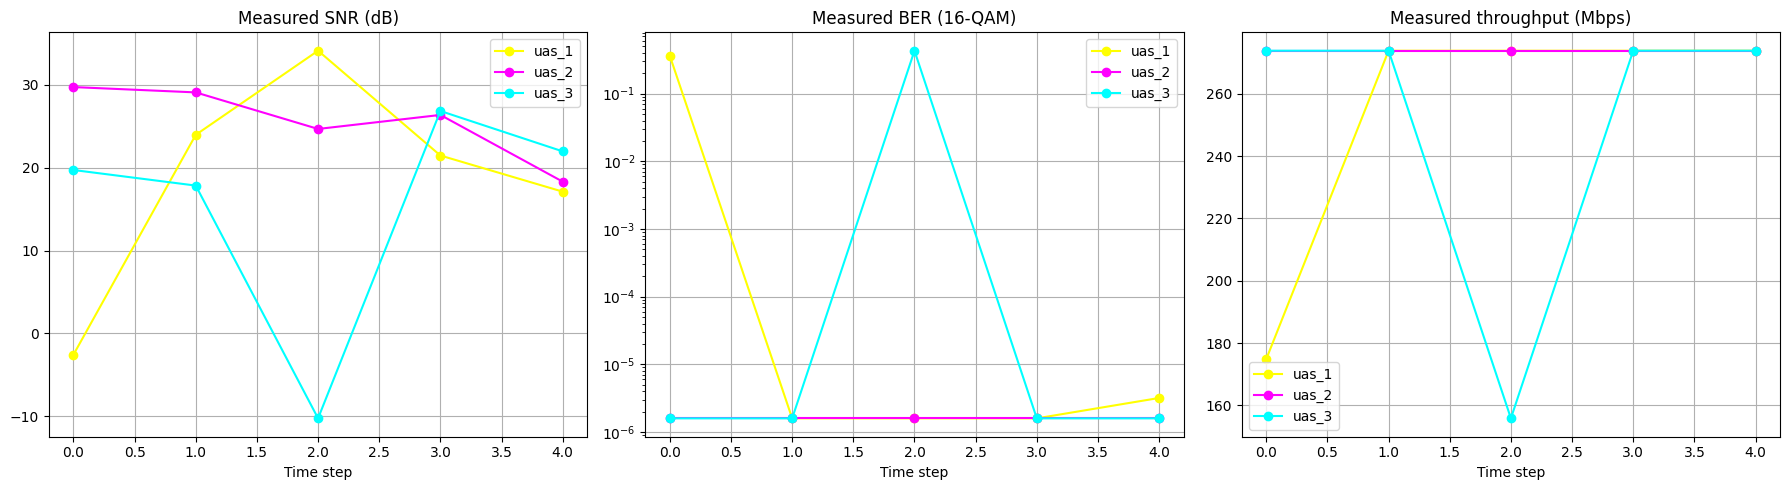

In [8]:
# SNR, BER and throughput, measured off the decoded OFDM frames
if plots_on and jcas_results:
    plot_jcas_kpis(jcas_results, scene)

Range-Doppler — Step 0: peak  R=12.2 m, v=+9.3 m/s
Range-Doppler — Step 0: truth R=10.9 m, v=+9.2 m/s
Range-Doppler — Step 0: truth R=23.6 m, v=+5.3 m/s
Range-Doppler — Step 0: truth R=39.3 m, v=+3.8 m/s
Range-Doppler — Step 1: peak  R=25.9 m, v=+18.6 m/s
Range-Doppler — Step 1: truth R=26.8 m, v=+18.6 m/s
Range-Doppler — Step 1: truth R=37.8 m, v=+19.8 m/s
Range-Doppler — Step 1: truth R=52.4 m, v=+20.1 m/s
Range-Doppler — Step 2: peak  R=59.4 m, v=+23.3 m/s
Range-Doppler — Step 2: truth R=46.0 m, v=+19.6 m/s
Range-Doppler — Step 2: truth R=59.6 m, v=+23.1 m/s
Range-Doppler — Step 2: truth R=75.8 m, v=+25.7 m/s
Range-Doppler — Step 3: peak  R=65.5 m, v=+18.6 m/s
Range-Doppler — Step 3: truth R=65.7 m, v=+19.8 m/s
Range-Doppler — Step 3: truth R=83.3 m, v=+24.0 m/s
Range-Doppler — Step 3: truth R=102.7 m, v=+27.8 m/s
Range-Doppler — Step 4: peak  R=106.6 m, v=+23.3 m/s
Range-Doppler — Step 4: truth R=85.6 m, v=+19.9 m/s
Range-Doppler — Step 4: truth R=107.5 m, v=+24.4 m/s
Range-Doppler

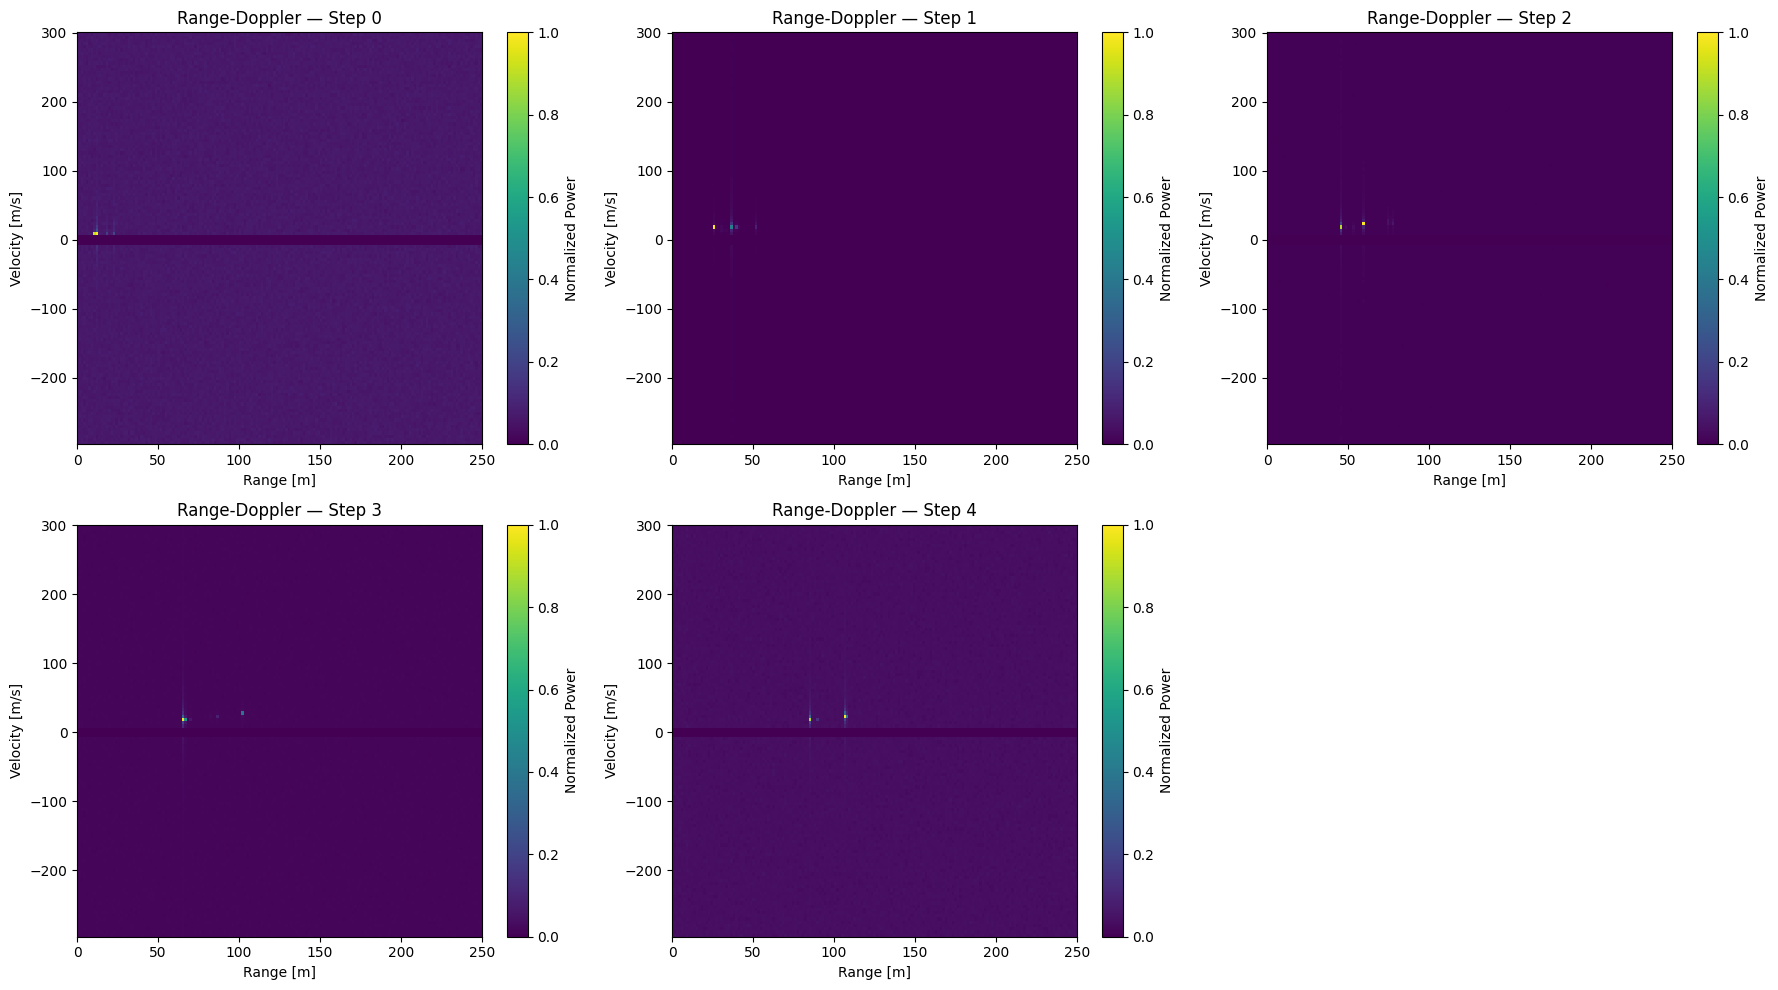

In [9]:
if plots_on and sensing_on and sensing_cubes:
    n_steps_plotted = len(sensing_cubes)
    ncols = 3
    nrows = -(-n_steps_plotted // ncols)  # ceil division

    fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
    for t_idx in range(n_steps_plotted):
        ax = fig.add_subplot(nrows, ncols, t_idx + 1)
        plot_range_doppler(
            sensing_cubes[t_idx],
            max_range_m=250,
            ax=ax,
            title=f"Range-Doppler — Step {t_idx}",
            ground_truth=sensing_ground_truth[t_idx],
        )
    plt.tight_layout()
    plt.show()


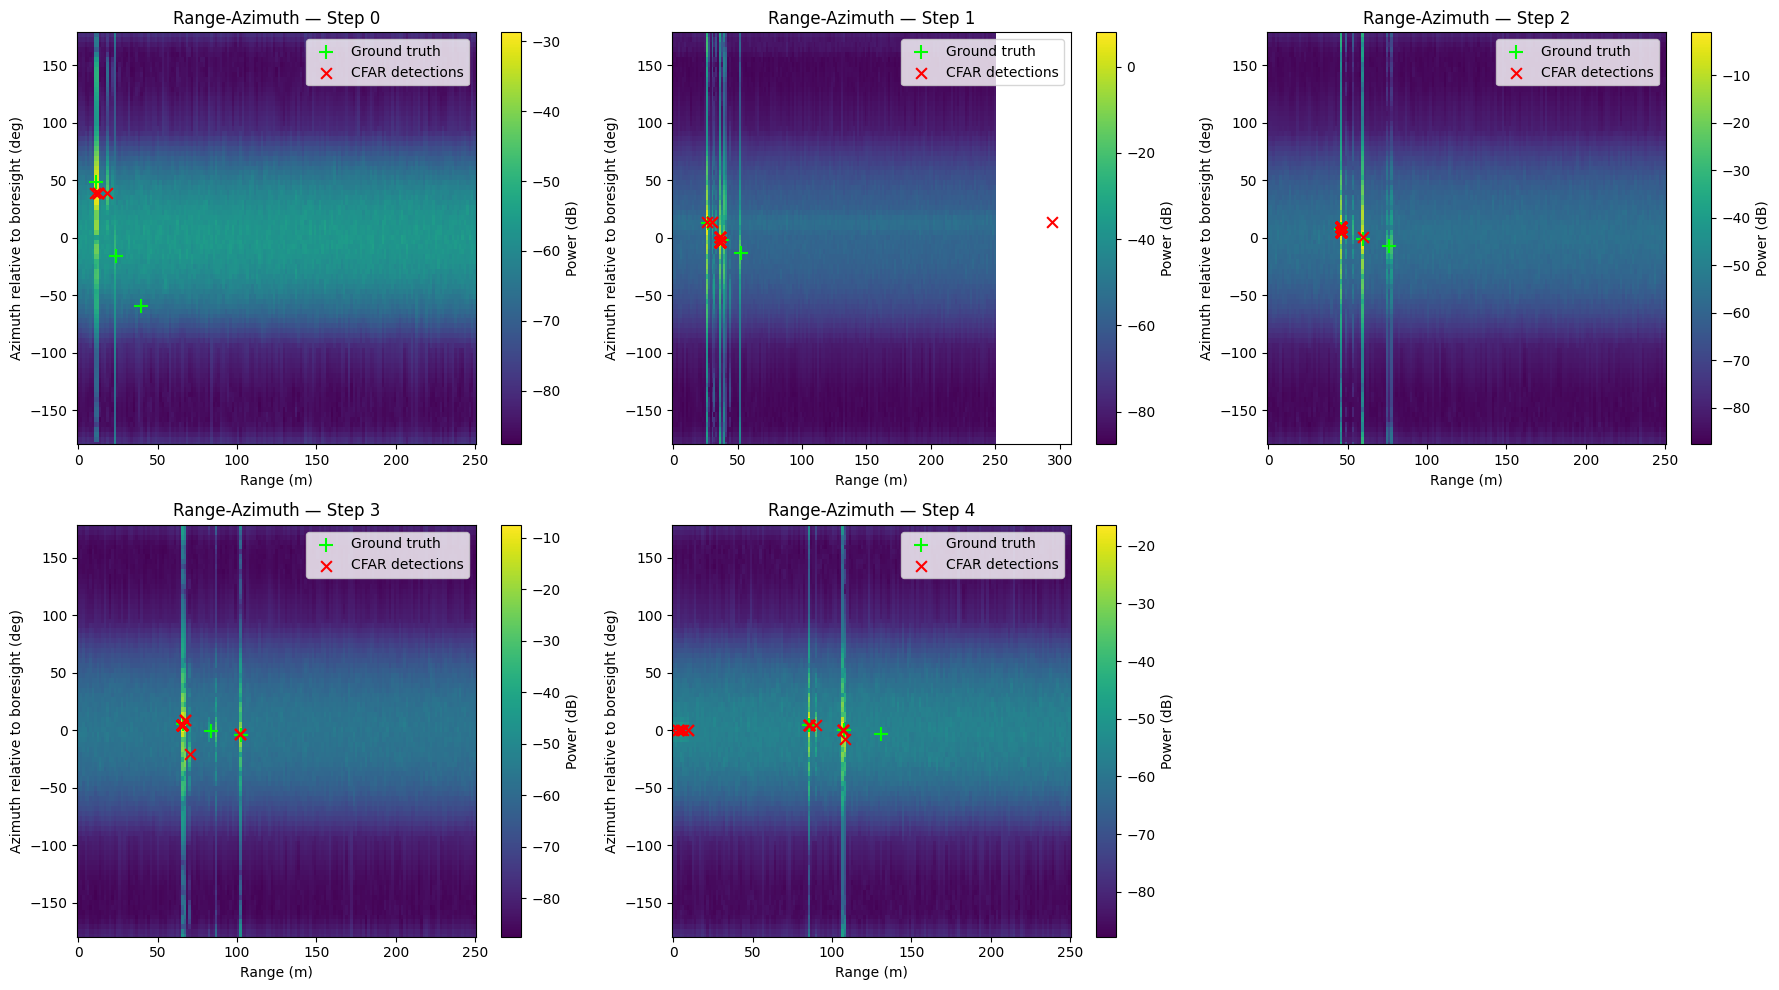

In [10]:
# boresight_azimuth_rad re-centers the azimuth axis, so 0 deg is dead ahead
if plots_on and sensing_on and sensing_cubes:
    n_steps_plotted = len(sensing_cubes)
    ncols = 3
    nrows = -(-n_steps_plotted // ncols)  # ceil division
    boresight_az = world_to_spherical(bs_position, look_at_point)[1]

    fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
    for t_idx in range(n_steps_plotted):
        ax = fig.add_subplot(nrows, ncols, t_idx + 1)
        gt_range_azimuth = [world_to_spherical(bs_position, pos)[:2] for pos in sensing_ground_truth_pos[t_idx]]
        detections = detect_targets(sensing_cubes[t_idx])
        plot_range_angle(
            sensing_cubes[t_idx],
            ground_truth=gt_range_azimuth,
            detections=detections,
            max_range_m=250,
            ax=ax,
            title=f"Range-Azimuth — Step {t_idx}",
            boresight_azimuth_rad=boresight_az,
        )
    plt.tight_layout()
    plt.show()


In [11]:
if plots_on:
    scene.preview()